# BigAlpha 2026：盘口压力低冲击因子研究

## tl;dr

这个 notebook 构造一个基于 1 分钟盘口和成交数据的日频 alpha 因子：`obp_low_impact_tail`。

核心想法：如果一只股票在日内尤其是尾盘出现更强的买盘队列压力，同时价差、冲击成本和剧烈日内波动较低，说明买盘更像稳定吸收流动性，而不是短暂追涨。

本版按 `bigquant_official_examples/official_examples_reuse_notes.md` 做了结构调整：

- 因子生成复用“`dai.query + pandas` 明确流程”的写法。
- 因子评价复用官方因子分析示例的闭环：覆盖率、Rank IC、分组收益、多空收益、换手、年度稳定性和官方因子相关性。
- 提交接口固定为 `main(start_date, end_date)`，只返回 `date`、`instrument`、`factor` 三列。
- 附带 `build_factor`、`evaluate_factor`、`factor_to_position` 三个复用接口，方便后续批量因子研究或接回测。

本地没有 BigQuant `dai` 数据访问时，数据单元会跳过执行；在 BigQuant Notebook 环境中从上到下运行即可生成结果。


## Context & Methods

### 官方示例复用路线

本 notebook 不直接搬运某个官方示例，而是组合复用：

- 因子生成：参考 `4.小市值策略_股票_代码版.ipynb`，用 `dai.query` 拉取数据后在 pandas 中显式计算。
- 因子评价：参考 `8.因子分析.ipynb`，输入统一为 `date`、`instrument`、`factor`，再计算 IC、分组收益、换手、年度稳定性和中性化结果。
- 提交检查：沿用 BigAlpha 比赛要求，最终输出只保留三列，不混入诊断字段。

### 因子定义

数据源：`bigalpha_2026_stock_bar1m` 的 1 分钟 OHLC、累计成交量/金额/笔数、1-5 档买卖盘口量和委托笔数。

日频因子由以下组件合成，并在每日横截面做稳健去极值和标准化：

- 买卖盘口深度不平衡：`sum(bid_volume1..5) - sum(ask_volume1..5)`。
- 买卖委托笔数不平衡：`sum(bid_num_orders1..5) - sum(ask_num_orders1..5)`。
- 尾盘压力变化：最后 25% 分钟的盘口压力减去最早 25% 分钟的盘口压力。
- 低交易摩擦：买卖一档价差越小越好。
- 低冲击成本：单位成交金额对应的分钟价格波动越小越好。
- 低日内极端波动：减少纯追涨/异常波动暴露。

### Evaluation

评价使用 `bigalpha_2026_exposure.ret` 构造未来 1 日收益标签：因子日期 `t` 对应同一股票下一条交易记录的 `ret`。评价包括：

- 覆盖率、缺失率、横截面分布。
- Rank IC、IC_IR、IC 胜率和 t 值。
- 五分组收益、多空组合、年化收益、Sharpe、最大回撤、胜率。
- Top/Bottom 组合换手和最近日期样本检查。
- 分年度稳定性。
- 可选的风格/行业中性化后评价。
- 可选的官方因子库相关性检查，用于判断 Elastic Net 增量价值风险。

### Key Assumptions

- 字段字典显示 `volume`、`amount`、`deal_number` 为当日累计值，所以计算前先转成分钟增量。
- 因子本身只使用当日及之前可见的盘口数据；未来收益只用于离线评价。
- 默认评估区间较短，先做 smoke test；正式研究建议逐年扩展到 2019-2024。
- 平台最终会做去极值、标准化和 BARRA 风格剔除；这里的中性化评价用于提前发现因子是否主要来自风格暴露。


In [1]:
import math
import warnings
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

try:
    import dai
except ImportError:
    dai = None

print("dai available:", dai is not None)


dai available: True


In [2]:
# ========== Parameters ==========
FACTOR_NAME = "obp_low_impact_tail"
OFFICIAL_REUSE_NOTES = "bigquant_official_examples/official_examples_reuse_notes.md"

# 先用一个较短区间跑通。跑通后再扩展到 2024 全年、2023-2024、最后扩展 2019-2024。
EVAL_START = "2024-01-01"
EVAL_END = "2024-03-31"

# 提交函数 main() 的默认生成区间。正式提交前按平台要求调整。
SUBMISSION_START = EVAL_START
SUBMISSION_END = EVAL_END

RETURN_HORIZON_DAYS = 1
QUANTILES = 5
HOLD_COUNT = 100
POSITION_TOTAL = 1.0
MIN_DAILY_NAMES = 30
MIN_FACTOR_COVERAGE = 0.60

NEUTRALIZE_FOR_EVAL = True
AUTO_FLIP_FOR_EVAL = True
RUN_FACTORLIB_CORR = True

STYLE_COLS = [
    "BETA", "BTOP", "SIZE", "SIZENL", "GROWTH",
    "RESVOL", "EARNYILD", "LEVERAGE", "LIQUIDTY", "MOMENTUM",
]

FACTORLIB_CHECK_COLS = [
    "pb", "pe_ttm", "ps_ttm", "atr_14", "cci_14", "ema_20", "sma_20", "rsi_12",
    "momentum_5", "reversal_5", "daily_return", "volatility_5", "turn", "amount",
    "volume", "float_market_cap", "total_market_cap", "roe_avg_ttm", "roa_avg_ttm",
    "macd_diff_12_26_9", "macd_dea_12_26_9", "macd_hist_12_26_9",
    "netflow_amount_main", "netflow_amount_rate_main", "net_active_buy_amount_main",
]

BAR_COLUMNS = [
    "date", "instrument", "open", "high", "low", "close", "volume", "amount", "deal_number",
    "ask_price1", "bid_price1",
    "ask_volume1", "ask_volume2", "ask_volume3", "ask_volume4", "ask_volume5",
    "bid_volume1", "bid_volume2", "bid_volume3", "bid_volume4", "bid_volume5",
    "ask_num_orders1", "ask_num_orders2", "ask_num_orders3", "ask_num_orders4", "ask_num_orders5",
    "bid_num_orders1", "bid_num_orders2", "bid_num_orders3", "bid_num_orders4", "bid_num_orders5",
]


## Data

下面的读取函数依赖 BigQuant 的 `dai.query`。如果在本地运行会因为没有 `dai` 而停止；在 BigQuant Notebook 环境里直接运行即可。


In [3]:
def require_dai():
    if dai is None:
        raise RuntimeError(
            "当前环境没有 dai。请在 BigQuant Notebook 中运行，或先配置 BigQuant 数据访问环境。"
        )


def normalize_date(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series).dt.normalize()


def calendar_buffer(end_date: str, days: int = 14) -> str:
    return (pd.Timestamp(end_date) + pd.Timedelta(days=days)).strftime("%Y-%m-%d")


def iter_month_ranges(start_date: str, end_date: str) -> Iterable[tuple[str, str]]:
    start = pd.Timestamp(start_date).normalize()
    end = pd.Timestamp(end_date).normalize()
    current = start
    while current <= end:
        month_end = (current + pd.offsets.MonthEnd(0)).normalize()
        chunk_end = min(month_end, end)
        yield current.strftime("%Y-%m-%d"), chunk_end.strftime("%Y-%m-%d")
        current = chunk_end + pd.Timedelta(days=1)


def assert_columns(df: pd.DataFrame, required_cols: list[str], frame_name: str) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{frame_name} 缺少字段: {missing}")


def empty_factor_frame(debug: bool = False) -> pd.DataFrame:
    base_cols = ["date", "instrument", "factor"]
    debug_cols = [
        "depth_pressure", "order_pressure", "pressure_shift", "spread_mean",
        "impact_mean", "intraday_return", "minutes", "amount_delta_sum",
    ]
    cols = base_cols + debug_cols if debug else base_cols
    return pd.DataFrame(columns=cols)


def canonical_factor_frame(factor_data: pd.DataFrame) -> pd.DataFrame:
    out = factor_data[["date", "instrument", "factor"]].copy()
    out["date"] = normalize_date(out["date"])
    out["instrument"] = out["instrument"].astype("string")
    out["factor"] = pd.to_numeric(out["factor"], errors="coerce").astype("float64")
    return out.sort_values(["date", "instrument"]).reset_index(drop=True)


def fetch_bar1m(start_date: str, end_date: str) -> pd.DataFrame:
    require_dai()
    sql = f"""
    SELECT {", ".join(BAR_COLUMNS)}
    FROM bigalpha_2026_stock_bar1m
    """
    df = dai.query(
        sql,
        filters={"date": [f"{start_date} 00:00:00", f"{end_date} 23:59:59"]},
    ).df()
    assert_columns(df, BAR_COLUMNS, "bar1m")
    return df


def fetch_exposure(start_date: str, end_date: str, horizon_days: int = 1) -> pd.DataFrame:
    require_dai()
    buffered_end = calendar_buffer(end_date, days=max(14, horizon_days * 7 + 7))
    exposure_cols = ["date", "instrument", "ret", "float_market_cap", "industry_level1_code"] + STYLE_COLS
    sql = f"""
    SELECT {", ".join(exposure_cols)}
    FROM bigalpha_2026_exposure
    """
    df = dai.query(
        sql,
        filters={"date": [f"{start_date} 00:00:00", f"{buffered_end} 23:59:59"]},
    ).df()
    assert_columns(df, ["date", "instrument", "ret"], "exposure")
    return df


def fetch_factorlib(start_date: str, end_date: str, factor_cols: list[str]) -> pd.DataFrame:
    require_dai()
    cols = ["date", "instrument"] + factor_cols
    sql = f"""
    SELECT {", ".join(cols)}
    FROM bigalpha_2026_factorlib
    """
    df = dai.query(
        sql,
        filters={"date": [f"{start_date} 00:00:00", f"{end_date} 23:59:59"]},
    ).df()
    assert_columns(df, ["date", "instrument"], "factorlib")
    return df


## Factor Construction

`build_factor_from_bar1m` 是核心函数。它只依赖当日分钟数据，输出既包含提交需要的三列，也保留诊断列方便分析。


In [4]:
def safe_divide(numerator, denominator):
    denominator = pd.Series(denominator).replace(0, np.nan)
    return pd.Series(numerator) / denominator


def robust_zscore(s: pd.Series, clip_n_mad: float = 5.0) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if x.notna().sum() < 5:
        return pd.Series(np.nan, index=s.index)

    median = x.median()
    mad = (x - median).abs().median()
    if pd.notna(mad) and mad > 0:
        width = clip_n_mad * 1.4826 * mad
        clipped = x.clip(median - width, median + width)
    else:
        lo, hi = x.quantile([0.01, 0.99])
        clipped = x.clip(lo, hi)

    std = clipped.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=s.index)
    return (clipped - clipped.mean()) / std


def add_daily_zscore(df: pd.DataFrame, col: str, out_col: Optional[str] = None) -> pd.DataFrame:
    out_col = out_col or f"z_{col}"
    df[out_col] = df.groupby("date", group_keys=False)[col].transform(robust_zscore)
    return df


def build_factor_from_bar1m(bar1m: pd.DataFrame) -> pd.DataFrame:
    df = bar1m.copy()
    if df.empty:
        return empty_factor_frame(debug=True)

    assert_columns(df, BAR_COLUMNS, "bar1m")
    df["bar_time"] = pd.to_datetime(df["date"])
    df["date"] = df["bar_time"].dt.normalize()
    df = df.sort_values(["instrument", "date", "bar_time"]).reset_index(drop=True)

    numeric_cols = [c for c in df.columns if c not in {"instrument", "bar_time", "date"}]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    intraday_group = df.groupby(["instrument", "date"], sort=False)

    # 字段字典标注这三列是当日累计值；转为分钟增量后再计算流动性权重和冲击成本。
    for col in ["volume", "amount", "deal_number"]:
        delta = intraday_group[col].diff()
        first_value = intraday_group[col].transform("first")
        df[f"{col}_delta"] = delta.where(delta.notna(), first_value)
        df[f"{col}_delta"] = df[f"{col}_delta"].where(df[f"{col}_delta"] >= 0, np.nan)

    bid_volume_cols = [f"bid_volume{i}" for i in range(1, 6)]
    ask_volume_cols = [f"ask_volume{i}" for i in range(1, 6)]
    bid_order_cols = [f"bid_num_orders{i}" for i in range(1, 6)]
    ask_order_cols = [f"ask_num_orders{i}" for i in range(1, 6)]

    df["bid_depth"] = df[bid_volume_cols].sum(axis=1, min_count=1)
    df["ask_depth"] = df[ask_volume_cols].sum(axis=1, min_count=1)
    df["bid_orders"] = df[bid_order_cols].sum(axis=1, min_count=1)
    df["ask_orders"] = df[ask_order_cols].sum(axis=1, min_count=1)

    df["depth_imbalance"] = safe_divide(
        df["bid_depth"] - df["ask_depth"],
        df["bid_depth"] + df["ask_depth"],
    ).clip(-1, 1)
    df["order_imbalance"] = safe_divide(
        df["bid_orders"] - df["ask_orders"],
        df["bid_orders"] + df["ask_orders"],
    ).clip(-1, 1)

    df["mid"] = (df["ask_price1"] + df["bid_price1"]) / 2
    df["spread"] = safe_divide(df["ask_price1"] - df["bid_price1"], df["mid"]).clip(lower=0)
    df["mid_ret"] = intraday_group["mid"].pct_change()
    df["abs_mid_ret"] = df["mid_ret"].abs()

    amount_delta = df["amount_delta"].clip(lower=0)
    df["liquidity_weight"] = np.log1p(amount_delta).replace(0, np.nan)
    df["impact_cost"] = df["abs_mid_ret"] / np.log1p(amount_delta).replace(0, np.nan)

    df["minute_idx"] = intraday_group.cumcount()
    df["minute_count"] = intraday_group["bar_time"].transform("size")
    df["is_early"] = df["minute_idx"] < df["minute_count"] * 0.25
    df["is_late"] = df["minute_idx"] >= df["minute_count"] * 0.75

    w = df["liquidity_weight"].fillna(0.0)
    df["depth_x_w"] = df["depth_imbalance"] * w
    df["order_x_w"] = df["order_imbalance"] * w
    df["early_depth_x_w"] = np.where(df["is_early"], df["depth_imbalance"] * w, 0.0)
    df["late_depth_x_w"] = np.where(df["is_late"], df["depth_imbalance"] * w, 0.0)
    df["early_w"] = np.where(df["is_early"], w, 0.0)
    df["late_w"] = np.where(df["is_late"], w, 0.0)

    daily_group = df.groupby(["date", "instrument"], sort=False)
    daily = daily_group.agg(
        minutes=("bar_time", "count"),
        amount_delta_sum=("amount_delta", "sum"),
        deal_delta_sum=("deal_number_delta", "sum"),
        depth_mean=("depth_imbalance", "mean"),
        order_mean=("order_imbalance", "mean"),
        spread_mean=("spread", "mean"),
        impact_mean=("impact_cost", "mean"),
        abs_mid_ret_mean=("abs_mid_ret", "mean"),
        open_px=("open", "first"),
        close_px=("close", "last"),
        w_sum=("liquidity_weight", "sum"),
        depth_x_w=("depth_x_w", "sum"),
        order_x_w=("order_x_w", "sum"),
        early_depth_x_w=("early_depth_x_w", "sum"),
        late_depth_x_w=("late_depth_x_w", "sum"),
        early_w=("early_w", "sum"),
        late_w=("late_w", "sum"),
    ).reset_index()

    daily["depth_pressure"] = np.where(
        daily["w_sum"] > 0,
        daily["depth_x_w"] / daily["w_sum"],
        daily["depth_mean"],
    )
    daily["order_pressure"] = np.where(
        daily["w_sum"] > 0,
        daily["order_x_w"] / daily["w_sum"],
        daily["order_mean"],
    )
    daily["early_depth_pressure"] = np.where(
        daily["early_w"] > 0,
        daily["early_depth_x_w"] / daily["early_w"],
        np.nan,
    )
    daily["late_depth_pressure"] = np.where(
        daily["late_w"] > 0,
        daily["late_depth_x_w"] / daily["late_w"],
        np.nan,
    )
    daily["pressure_shift"] = daily["late_depth_pressure"] - daily["early_depth_pressure"]
    daily["intraday_return"] = safe_divide(daily["close_px"], daily["open_px"]) - 1
    daily["neg_spread"] = -daily["spread_mean"]
    daily["neg_impact"] = -daily["impact_mean"]
    daily["neg_abs_intraday_return"] = -daily["intraday_return"].abs()

    component_weights = {
        "depth_pressure": 0.35,
        "order_pressure": 0.20,
        "pressure_shift": 0.30,
        "neg_spread": 0.15,
        "neg_impact": 0.15,
        "neg_abs_intraday_return": 0.10,
    }
    for component in component_weights:
        daily = add_daily_zscore(daily, component, f"z_{component}")

    daily["factor_raw"] = 0.0
    for component, weight in component_weights.items():
        daily["factor_raw"] += weight * daily[f"z_{component}"].fillna(0.0)

    daily = add_daily_zscore(daily, "factor_raw", "factor")
    daily["factor"] = pd.to_numeric(daily["factor"], errors="coerce").astype("float64")
    return daily.sort_values(["date", "instrument"]).reset_index(drop=True)


def build_factor_dataset(start_date: str, end_date: str) -> pd.DataFrame:
    parts = []
    for chunk_start, chunk_end in iter_month_ranges(start_date, end_date):
        print(f"loading bar1m {chunk_start} -> {chunk_end}")
        bars = fetch_bar1m(chunk_start, chunk_end)
        factor_chunk = build_factor_from_bar1m(bars)
        parts.append(factor_chunk)
        print(f"  rows: bars={len(bars):,}, factor={len(factor_chunk):,}")
    if not parts:
        return empty_factor_frame(debug=True)
    result = pd.concat(parts, ignore_index=True)
    result = result.drop_duplicates(["date", "instrument"], keep="last")
    return result.sort_values(["date", "instrument"]).reset_index(drop=True)


def build_factor(start_date: str, end_date: str) -> pd.DataFrame:
    """复用接口：返回 date、instrument、factor 三列。"""
    factor_data = build_factor_dataset(start_date, end_date)
    factor_data = factor_data[
        (factor_data["date"] >= pd.Timestamp(start_date))
        & (factor_data["date"] <= pd.Timestamp(end_date))
    ]
    return canonical_factor_frame(factor_data)


def main(start_date: Optional[str] = None, end_date: Optional[str] = None) -> pd.DataFrame:
    """BigAlpha 提交入口：返回 date、instrument、factor 三列。"""
    start_date = start_date or SUBMISSION_START
    end_date = end_date or SUBMISSION_END
    return build_factor(start_date, end_date)


In [5]:
# 构造因子。首次运行建议保持默认短区间；确认速度和内存后再扩大 EVAL_START/EVAL_END。
if dai is None:
    print("Skip factor construction: 当前环境没有 dai。请在 BigQuant Notebook 环境中运行本单元。")
    factor_debug = empty_factor_frame(debug=True)
    factor = empty_factor_frame(debug=False)
else:
    factor_debug = build_factor_dataset(EVAL_START, EVAL_END)
    factor = canonical_factor_frame(factor_debug)

print(factor.shape)
display(factor.head())

debug_preview_cols = [
    "date", "instrument", "factor", "depth_pressure", "order_pressure", "pressure_shift",
    "spread_mean", "impact_mean", "intraday_return", "minutes", "amount_delta_sum",
]
available_debug_cols = [c for c in debug_preview_cols if c in factor_debug.columns]
display(factor_debug[available_debug_cols].head())


loading bar1m 2024-01-01 -> 2024-01-31
  rows: bars=11,508,240, factor=47,951
loading bar1m 2024-02-01 -> 2024-02-29
  rows: bars=7,852,320, factor=32,718
loading bar1m 2024-03-01 -> 2024-03-31
  rows: bars=10,991,760, factor=45,799
(126468, 3)


,date,instrument,factor
0,2024-01-02,000006.SZ,0.028294
1,2024-01-02,000011.SZ,-0.376783
2,2024-01-02,000012.SZ,-1.269057
3,2024-01-02,000016.SZ,-0.062515
4,2024-01-02,000019.SZ,-0.842500


,date,instrument,factor,depth_pressure,order_pressure,pressure_shift,spread_mean,impact_mean,intraday_return,minutes,amount_delta_sum
0,2024-01-02,000006.SZ,0.028294,0.223604,0.087312,-0.069995,0.002212,0.000050,-0.024018,240,58484292.0
1,2024-01-02,000011.SZ,-0.376783,0.148438,0.057569,-0.464362,0.001226,0.000043,-0.004510,240,12680816.0
2,2024-01-02,000012.SZ,-1.269057,-0.273509,-0.292323,-0.171698,0.001795,0.000028,0.005405,240,25115344.0
3,2024-01-02,000016.SZ,-0.062515,0.499125,0.215195,-0.000399,0.002449,0.000113,-0.073563,240,157784368.0
4,2024-01-02,000019.SZ,-0.842500,-0.198264,-0.264474,-0.010357,0.001330,0.000037,0.015979,240,25484978.0


## Results

以下评价函数会把因子与未来收益对齐，计算 IC、分组回测、多空曲线和年度稳定性。


In [6]:
def prepare_forward_returns(exposure: pd.DataFrame, horizon_days: int = 1) -> pd.DataFrame:
    if exposure.empty:
        return exposure.copy()
    out = exposure.copy()
    out["date"] = normalize_date(out["date"])
    out = out.sort_values(["instrument", "date"]).reset_index(drop=True)
    out[f"fwd_ret_{horizon_days}d"] = out.groupby("instrument")["ret"].shift(-horizon_days)
    return out


def neutralize_factor_by_date(
    panel: pd.DataFrame,
    factor_col: str = "factor",
    style_cols: Optional[list[str]] = None,
    industry_col: str = "industry_level1_code",
) -> pd.Series:
    style_cols = style_cols or []
    residual = pd.Series(np.nan, index=panel.index, dtype="float64")

    for date, group in panel.groupby("date", sort=False):
        y = pd.to_numeric(group[factor_col], errors="coerce")
        x_parts = []
        available_styles = [c for c in style_cols if c in group.columns]
        if available_styles:
            style_frame = group[available_styles].apply(pd.to_numeric, errors="coerce")
            style_frame = style_frame.replace([np.inf, -np.inf], np.nan)
            style_frame = style_frame.fillna(style_frame.median())
            x_parts.append(style_frame)

        if industry_col in group.columns:
            industry_dummies = pd.get_dummies(group[industry_col].astype("string"), prefix="ind", dummy_na=False)
            x_parts.append(industry_dummies)

        valid_y = y.notna()
        if not x_parts or valid_y.sum() < MIN_DAILY_NAMES:
            residual.loc[group.index] = y
            continue

        x_frame = pd.concat(x_parts, axis=1)
        x_frame = x_frame.loc[:, x_frame.nunique(dropna=True) > 1]
        x_frame = x_frame.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        valid = valid_y & x_frame.notna().all(axis=1)

        if valid.sum() < max(MIN_DAILY_NAMES, x_frame.shape[1] + 5):
            residual.loc[group.index] = y
            continue

        x_matrix = np.column_stack([np.ones(valid.sum()), x_frame.loc[valid].to_numpy(dtype="float64")])
        y_vector = y.loc[valid].to_numpy(dtype="float64")
        beta = np.linalg.lstsq(x_matrix, y_vector, rcond=None)[0]
        residual.loc[group.index[valid]] = y_vector - x_matrix @ beta
        residual.loc[group.index[~valid]] = y.loc[~valid]

    result = panel[["date"]].copy()
    result["residual"] = residual
    return result.groupby("date", group_keys=False)["residual"].transform(robust_zscore)


def make_eval_panel(
    factor_data: pd.DataFrame,
    exposure_data: pd.DataFrame,
    horizon_days: int = 1,
    neutralize: bool = True,
) -> pd.DataFrame:
    if factor_data.empty or exposure_data.empty:
        ret_col = f"fwd_ret_{horizon_days}d"
        cols = ["date", "instrument", "factor", "factor_eval", ret_col, "ret", "float_market_cap", "industry_level1_code"]
        return pd.DataFrame(columns=cols)

    factor_clean = canonical_factor_frame(factor_data)
    fwd = prepare_forward_returns(exposure_data, horizon_days=horizon_days)
    ret_col = f"fwd_ret_{horizon_days}d"
    keep_cols = [
        "date", "instrument", ret_col, "ret", "float_market_cap", "industry_level1_code",
    ] + [c for c in STYLE_COLS if c in fwd.columns]
    fwd["date"] = normalize_date(fwd["date"])
    panel = factor_clean.merge(fwd[keep_cols], on=["date", "instrument"], how="inner")
    panel = panel.replace([np.inf, -np.inf], np.nan)

    if neutralize:
        panel["factor_eval"] = neutralize_factor_by_date(panel, factor_col="factor", style_cols=STYLE_COLS)
    else:
        panel["factor_eval"] = panel.groupby("date", group_keys=False)["factor"].transform(robust_zscore)

    return panel


if dai is None or factor.empty:
    print("Skip evaluation data: 没有 dai 或 factor 为空。")
    exposure = pd.DataFrame()
    eval_panel = make_eval_panel(factor, exposure, horizon_days=RETURN_HORIZON_DAYS, neutralize=NEUTRALIZE_FOR_EVAL)
else:
    exposure = fetch_exposure(EVAL_START, EVAL_END, horizon_days=RETURN_HORIZON_DAYS)
    eval_panel = make_eval_panel(
        factor,
        exposure,
        horizon_days=RETURN_HORIZON_DAYS,
        neutralize=NEUTRALIZE_FOR_EVAL,
    )

print(eval_panel.shape)
display(eval_panel.head())


(57960, 18)


,date,instrument,factor,fwd_ret_1d,ret,float_market_cap,industry_level1_code,BETA,BTOP,SIZE,SIZENL,GROWTH,RESVOL,EARNYILD,LEVERAGE,LIQUIDTY,MOMENTUM,factor_eval
0,2024-01-02,000006.SZ,0.028294,0.008949,-0.026144,6.034444e+09,REALESTATE,-0.375241,2.257055,-1.787886,2.019119,-0.415285,1.255299,0.303362,1.799354,0.503722,0.142895,0.014221
1,2024-01-02,000012.SZ,-1.269057,0.005376,0.001795,1.091987e+10,CONMAT,-0.241113,0.680890,-0.670662,1.401428,0.510623,-1.294337,1.135007,-0.012157,-0.791513,-0.493489,-1.059456
2,2024-01-02,000016.SZ,-0.062515,0.002481,-0.033573,6.434273e+09,HOUSEAPP,1.077637,0.411391,-1.279322,2.020738,-1.627266,-0.967518,-3.299380,1.997111,-0.626434,-0.582091,-0.027099
3,2024-01-02,000019.SZ,-0.842500,0.000000,0.011936,3.175731e+09,AGRIFOREST,-0.690425,-0.204375,-1.384759,2.066652,-0.729105,-0.964030,-0.549651,-0.910103,-0.063920,0.247443,-0.646600
4,2024-01-02,000025.SZ,-0.563368,-0.011215,0.008799,6.304092e+09,CONGLOMERATES,0.404407,-1.236004,-1.641534,2.080594,-0.285151,-0.795932,-1.223933,-0.983368,-0.322242,0.010114,-0.216032


In [7]:
def factor_coverage(panel: pd.DataFrame, factor_col: str = "factor_eval", ret_col: Optional[str] = None) -> pd.DataFrame:
    ret_col = ret_col or f"fwd_ret_{RETURN_HORIZON_DAYS}d"
    columns = [
        "n", "factor_non_null", "ret_non_null", "factor_mean", "factor_std",
        "factor_min", "factor_max", "factor_coverage", "ret_coverage",
    ]
    if panel.empty or factor_col not in panel.columns or ret_col not in panel.columns:
        return pd.DataFrame(columns=columns)

    daily = panel.groupby("date").agg(
        n=("instrument", "count"),
        factor_non_null=(factor_col, lambda s: s.notna().sum()),
        ret_non_null=(ret_col, lambda s: s.notna().sum()),
        factor_mean=(factor_col, "mean"),
        factor_std=(factor_col, "std"),
        factor_min=(factor_col, "min"),
        factor_max=(factor_col, "max"),
    )
    daily["factor_coverage"] = daily["factor_non_null"] / daily["n"]
    daily["ret_coverage"] = daily["ret_non_null"] / daily["n"]
    return daily


def daily_spearman_ic(panel: pd.DataFrame, factor_col: str = "factor_eval", ret_col: Optional[str] = None) -> pd.Series:
    ret_col = ret_col or f"fwd_ret_{RETURN_HORIZON_DAYS}d"
    if panel.empty or factor_col not in panel.columns or ret_col not in panel.columns:
        return pd.Series(dtype="float64")

    def _ic(group: pd.DataFrame) -> float:
        valid = group[[factor_col, ret_col]].dropna()
        if len(valid) < MIN_DAILY_NAMES or valid[factor_col].nunique() < 2 or valid[ret_col].nunique() < 2:
            return np.nan
        return valid[factor_col].rank(method="average").corr(valid[ret_col].rank(method="average"))

    return panel.groupby("date").apply(_ic).dropna()


def summarize_ic(ic: pd.Series) -> pd.DataFrame:
    if ic.empty:
        return pd.DataFrame([{
            "days": 0,
            "mean_ic": np.nan,
            "median_ic": np.nan,
            "std_ic": np.nan,
            "ic_ir_ann": np.nan,
            "ic_t_stat": np.nan,
            "ic_positive_rate": np.nan,
        }])
    std = ic.std(ddof=1)
    return pd.DataFrame([{
        "days": int(ic.shape[0]),
        "mean_ic": ic.mean(),
        "median_ic": ic.median(),
        "std_ic": std,
        "ic_ir_ann": ic.mean() / std * math.sqrt(252) if std and pd.notna(std) else np.nan,
        "ic_t_stat": ic.mean() / std * math.sqrt(len(ic)) if std and pd.notna(std) else np.nan,
        "ic_positive_rate": (ic > 0).mean(),
    }])


ret_col = f"fwd_ret_{RETURN_HORIZON_DAYS}d"
coverage_daily = factor_coverage(eval_panel, factor_col="factor_eval", ret_col=ret_col)
ic_by_date = daily_spearman_ic(eval_panel, factor_col="factor_eval", ret_col=ret_col)
ic_summary = summarize_ic(ic_by_date)

if AUTO_FLIP_FOR_EVAL and not ic_by_date.empty and ic_by_date.mean() < 0:
    print("Mean IC is negative; flip factor_eval for evaluation only.")
    eval_panel["factor_eval"] = -eval_panel["factor_eval"]
    ic_by_date = daily_spearman_ic(eval_panel, factor_col="factor_eval", ret_col=ret_col)
    ic_summary = summarize_ic(ic_by_date)

if coverage_daily.empty:
    print("No coverage/IC output yet. Run in BigQuant Notebook with dai access.")
else:
    display(coverage_daily.describe().T)
display(ic_summary)
display(ic_by_date.tail())


Mean IC is negative; flip factor_eval for evaluation only.


,count,mean,std,min,25%,50%,75%,max
n,58.0,9.993103e+02,9.023730e-01,9.970000e+02,9.990000e+02,1.000000e+03,1.000000e+03,1.000000e+03
factor_non_null,58.0,9.993103e+02,9.023730e-01,9.970000e+02,9.990000e+02,1.000000e+03,1.000000e+03,1.000000e+03
ret_non_null,58.0,9.993103e+02,9.023730e-01,9.970000e+02,9.990000e+02,1.000000e+03,1.000000e+03,1.000000e+03
factor_mean,58.0,-3.651591e-18,1.470991e-17,-3.361786e-17,-1.411395e-17,-3.580469e-18,8.471869e-18,2.525757e-17
factor_std,58.0,1.000501e+00,4.529874e-07,1.000500e+00,1.000500e+00,1.000500e+00,1.000501e+00,1.000502e+00
factor_min,58.0,-3.759751e+00,6.664689e-01,-5.171301e+00,-4.296881e+00,-3.720790e+00,-3.218011e+00,-2.603675e+00
factor_max,58.0,4.043436e+00,6.186684e-01,2.618463e+00,3.799203e+00,4.276124e+00,4.531084e+00,4.742205e+00
factor_coverage,58.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ret_coverage,58.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


,days,mean_ic,median_ic,std_ic,ic_ir_ann,ic_t_stat,ic_positive_rate
0,58,0.000314,0.007292,0.0686,0.072773,0.034913,0.568966


date
2024-03-25    0.020931
2024-03-26    0.022402
2024-03-27   -0.011056
2024-03-28    0.005752
2024-03-29   -0.189686
dtype: float64

In [8]:
def assign_quantiles(panel: pd.DataFrame, factor_col: str = "factor_eval", quantiles: int = 5) -> pd.DataFrame:
    out = panel.copy()
    out["quantile"] = np.nan
    if out.empty or factor_col not in out.columns:
        return out

    def _assign(group: pd.DataFrame) -> pd.Series:
        valid = group[factor_col].dropna()
        labels = pd.Series(np.nan, index=group.index)
        min_names = max(quantiles * 5, MIN_DAILY_NAMES)
        if valid.shape[0] < min_names or valid.nunique() < quantiles:
            return labels
        ranks = valid.rank(method="first")
        labels.loc[valid.index] = pd.qcut(ranks, quantiles, labels=False, duplicates="drop") + 1
        return labels

    for _, group in out.groupby("date", sort=False):
        labels = _assign(group)
        out.loc[group.index, "quantile"] = labels.reindex(group.index)
    return out


def max_drawdown(nav: pd.Series) -> float:
    if nav.empty:
        return np.nan
    drawdown = nav / nav.cummax() - 1
    return drawdown.min()


def long_short_metrics(long_short_returns: pd.Series) -> pd.DataFrame:
    returns = long_short_returns.dropna()
    if returns.empty:
        return pd.DataFrame([{
            "days": 0,
            "mean_daily_return": np.nan,
            "annual_return": np.nan,
            "annual_vol": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "win_rate": np.nan,
        }])
    nav = (1 + returns).cumprod()
    ann_ret = nav.iloc[-1] ** (252 / len(returns)) - 1 if len(returns) > 0 else np.nan
    ann_vol = returns.std(ddof=1) * math.sqrt(252)
    return pd.DataFrame([{
        "days": int(len(returns)),
        "mean_daily_return": returns.mean(),
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": ann_ret / ann_vol if ann_vol and pd.notna(ann_vol) else np.nan,
        "max_drawdown": max_drawdown(nav),
        "win_rate": (returns > 0).mean(),
    }])


def quantile_backtest(panel: pd.DataFrame, factor_col: str = "factor_eval", ret_col: Optional[str] = None, quantiles: int = 5):
    ret_col = ret_col or f"fwd_ret_{RETURN_HORIZON_DAYS}d"
    qpanel = assign_quantiles(panel, factor_col=factor_col, quantiles=quantiles)
    if qpanel.empty or ret_col not in qpanel.columns:
        empty_returns = pd.DataFrame(columns=range(1, quantiles + 1))
        empty_series = pd.Series(dtype="float64")
        return qpanel, empty_returns, empty_returns.copy(), empty_series, empty_series, long_short_metrics(empty_series)

    qpanel = qpanel.dropna(subset=["quantile", ret_col])
    if qpanel.empty:
        empty_returns = pd.DataFrame(columns=range(1, quantiles + 1))
        empty_series = pd.Series(dtype="float64")
        return qpanel, empty_returns, empty_returns.copy(), empty_series, empty_series, long_short_metrics(empty_series)

    qpanel["quantile"] = qpanel["quantile"].astype(int)
    quantile_returns = qpanel.groupby(["date", "quantile"])[ret_col].mean().unstack("quantile").sort_index()
    quantile_returns = quantile_returns.reindex(columns=range(1, quantiles + 1))
    quantile_nav = (1 + quantile_returns.fillna(0.0)).cumprod()
    long_short_returns = quantile_returns[quantiles] - quantile_returns[1]
    long_short_nav = (1 + long_short_returns.fillna(0.0)).cumprod()
    summary = long_short_metrics(long_short_returns)
    return qpanel, quantile_returns, quantile_nav, long_short_returns, long_short_nav, summary


def membership_turnover(qpanel: pd.DataFrame, side_quantile: int) -> float:
    if qpanel.empty or "quantile" not in qpanel.columns:
        return np.nan
    members = qpanel[qpanel["quantile"] == side_quantile].groupby("date")["instrument"].apply(set).sort_index()
    if len(members) < 2:
        return np.nan
    turnovers = []
    prev = None
    for current in members:
        if prev is not None and len(prev) > 0:
            turnovers.append(1 - len(prev & current) / len(prev))
        prev = current
    return float(np.mean(turnovers)) if turnovers else np.nan


def top_bottom_sample(qpanel: pd.DataFrame, factor_col: str = "factor_eval", names_per_side: int = 5) -> pd.DataFrame:
    if qpanel.empty or factor_col not in qpanel.columns:
        return pd.DataFrame()
    latest_date = qpanel["date"].max()
    latest = qpanel[qpanel["date"] == latest_date].dropna(subset=[factor_col])
    top = latest.nlargest(names_per_side, factor_col).assign(side="top")
    bottom = latest.nsmallest(names_per_side, factor_col).assign(side="bottom")
    cols = ["date", "instrument", factor_col, "factor", "quantile", "side"]
    return pd.concat([top, bottom], ignore_index=True)[[c for c in cols if c in latest.columns or c == "side"]]


def evaluate_factor(
    factor_data: pd.DataFrame,
    exposure_data: pd.DataFrame,
    horizon_days: int = RETURN_HORIZON_DAYS,
    quantiles: int = QUANTILES,
    neutralize: bool = NEUTRALIZE_FOR_EVAL,
) -> dict:
    """复用接口：返回 IC、分组收益、换手、年度稳定性等评价对象。"""
    panel = make_eval_panel(factor_data, exposure_data, horizon_days=horizon_days, neutralize=neutralize)
    ret_name = f"fwd_ret_{horizon_days}d"
    coverage = factor_coverage(panel, factor_col="factor_eval", ret_col=ret_name)
    ic = daily_spearman_ic(panel, factor_col="factor_eval", ret_col=ret_name)
    qpanel_, qret_, qnav_, ls_ret_, ls_nav_, ls_summary_ = quantile_backtest(
        panel,
        factor_col="factor_eval",
        ret_col=ret_name,
        quantiles=quantiles,
    )
    ls_summary_["top_turnover"] = membership_turnover(qpanel_, quantiles)
    ls_summary_["bottom_turnover"] = membership_turnover(qpanel_, 1)
    return {
        "panel": panel,
        "coverage": coverage,
        "ic_by_date": ic,
        "ic_summary": summarize_ic(ic),
        "quantile_panel": qpanel_,
        "quantile_returns": qret_,
        "quantile_nav": qnav_,
        "long_short_returns": ls_ret_,
        "long_short_nav": ls_nav_,
        "long_short_summary": ls_summary_,
    }


qpanel, qret, qnav, ls_ret, ls_nav, ls_summary = quantile_backtest(
    eval_panel,
    factor_col="factor_eval",
    ret_col=ret_col,
    quantiles=QUANTILES,
)
ls_summary["top_turnover"] = membership_turnover(qpanel, QUANTILES)
ls_summary["bottom_turnover"] = membership_turnover(qpanel, 1)

if qret.empty:
    print("No quantile output yet. Run in BigQuant Notebook with dai access.")
else:
    display(qret.mean().to_frame("mean_daily_return_by_quantile"))
display(ls_summary)
display(top_bottom_sample(qpanel, factor_col="factor_eval", names_per_side=5))


,mean_daily_return_by_quantile
quantile,
1,-0.000409
2,-0.000346
3,-0.000868
4,-0.000499
5,-0.001336


,days,mean_daily_return,annual_return,annual_vol,sharpe,max_drawdown,win_rate,top_turnover,bottom_turnover
0,58,-0.000927,-0.211457,0.087994,-2.40308,-0.08342,0.482759,0.691316,0.707105


,date,instrument,factor_eval,factor,quantile,side
0,2024-03-29,601515.SH,4.226041,-3.365556,5,top
1,2024-03-29,688739.SH,3.002505,-2.355795,5,top
2,2024-03-29,600976.SH,2.684749,-2.022894,5,top
3,2024-03-29,601028.SH,2.652517,-2.385377,5,top
4,2024-03-29,002895.SZ,2.622208,-2.253655,5,top
5,2024-03-29,000737.SZ,-4.466859,3.589683,1,bottom
6,2024-03-29,001696.SZ,-4.006280,3.263948,1,bottom
7,2024-03-29,603730.SH,-3.242842,2.767619,1,bottom
8,2024-03-29,600007.SH,-3.235264,3.497435,1,bottom
9,2024-03-29,600821.SH,-3.010846,2.517954,1,bottom


In [9]:
def yearly_performance(ic: pd.Series, long_short_returns: pd.Series) -> pd.DataFrame:
    rows = []
    returns = long_short_returns.dropna()
    if ic.empty and returns.empty:
        return pd.DataFrame()

    ic_years = set(pd.DatetimeIndex(ic.index).year) if not ic.empty else set()
    ret_years = set(pd.DatetimeIndex(returns.index).year) if not returns.empty else set()
    years = sorted(ic_years.union(ret_years))
    for year in years:
        ic_y = ic[pd.DatetimeIndex(ic.index).year == year] if not ic.empty else pd.Series(dtype="float64")
        ret_y = returns[pd.DatetimeIndex(returns.index).year == year] if not returns.empty else pd.Series(dtype="float64")
        row = {"year": year}
        if not ic_y.empty:
            ic_std_y = ic_y.std(ddof=1)
            row.update({
                "mean_ic": ic_y.mean(),
                "ic_ir_ann": ic_y.mean() / ic_std_y * math.sqrt(252) if ic_std_y else np.nan,
                "ic_positive_rate": (ic_y > 0).mean(),
                "ic_days": len(ic_y),
            })
        if not ret_y.empty:
            nav_y = (1 + ret_y).cumprod()
            ann_vol_y = ret_y.std(ddof=1) * math.sqrt(252)
            ann_ret_y = nav_y.iloc[-1] ** (252 / len(ret_y)) - 1
            row.update({
                "ls_annual_return": ann_ret_y,
                "ls_sharpe": ann_ret_y / ann_vol_y if ann_vol_y and pd.notna(ann_vol_y) else np.nan,
                "ls_max_drawdown": max_drawdown(nav_y),
                "ls_win_rate": (ret_y > 0).mean(),
                "ls_days": len(ret_y),
            })
        rows.append(row)
    return pd.DataFrame(rows)


yearly_summary = yearly_performance(ic_by_date, ls_ret)
if yearly_summary.empty:
    print("No yearly performance yet.")
else:
    display(yearly_summary)


,year,mean_ic,ic_ir_ann,ic_positive_rate,ic_days,ls_annual_return,ls_sharpe,ls_max_drawdown,ls_win_rate,ls_days
0,2024,0.000314,0.072773,0.568966,58,-0.211457,-2.40308,-0.08342,0.482759,58


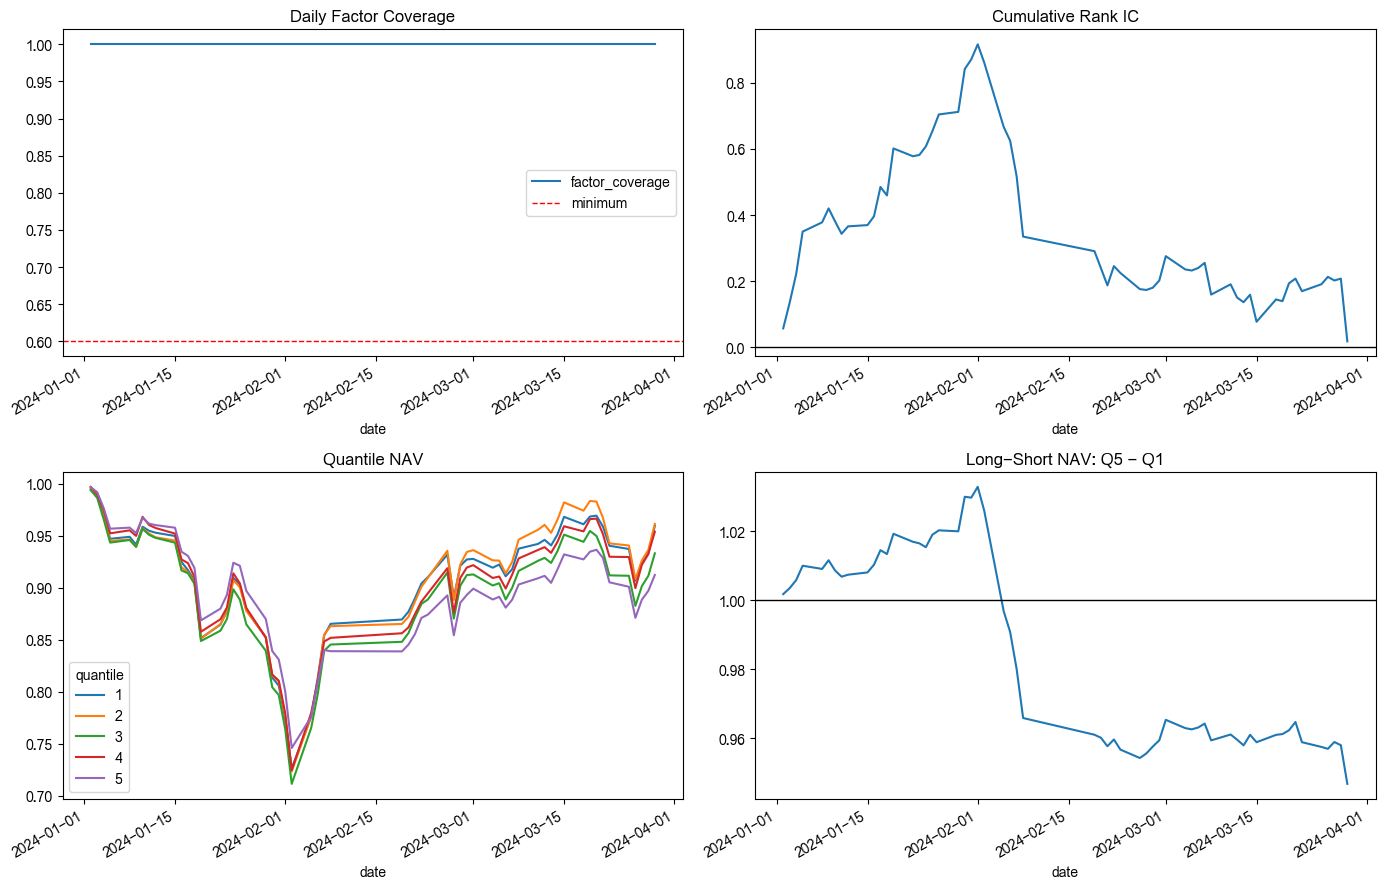

In [10]:
if coverage_daily.empty or ic_by_date.empty or qnav.empty or ls_nav.empty:
    print("Skip plots: evaluation outputs are empty.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    coverage_daily["factor_coverage"].plot(ax=axes[0, 0], title="Daily Factor Coverage")
    axes[0, 0].axhline(MIN_FACTOR_COVERAGE, color="red", linestyle="--", linewidth=1, label="minimum")
    axes[0, 0].legend()

    ic_by_date.cumsum().plot(ax=axes[0, 1], title="Cumulative Rank IC")
    axes[0, 1].axhline(0, color="black", linewidth=1)

    qnav.plot(ax=axes[1, 0], title="Quantile NAV")

    ls_nav.plot(ax=axes[1, 1], title=f"Long-Short NAV: Q{QUANTILES} - Q1")
    axes[1, 1].axhline(1, color="black", linewidth=1)

    plt.tight_layout()
    plt.show()


## Uniqueness Check

比赛 70% 权重来自全场 Elastic Net 增量贡献，因此不能只看 IC。下面检查本因子和官方因子库的平均横截面 rank 相关性。绝对相关性越高，越容易被已有因子解释。


In [11]:
def factorlib_rank_corr(
    panel: pd.DataFrame,
    factorlib: pd.DataFrame,
    factor_col: str = "factor_eval",
    candidate_cols: Optional[list[str]] = None,
) -> pd.DataFrame:
    if panel.empty or factorlib.empty or factor_col not in panel.columns:
        return pd.DataFrame(columns=["factorlib_col", "mean_rank_corr", "mean_abs_rank_corr", "days"])

    candidate_cols = candidate_cols or [c for c in factorlib.columns if c not in {"date", "instrument"}]
    base = factorlib.copy()
    base["date"] = normalize_date(base["date"])
    merged = panel[["date", "instrument", factor_col]].merge(base, on=["date", "instrument"], how="inner")

    rows = []
    for col in candidate_cols:
        if col not in merged.columns:
            continue
        daily_corr = []
        for _, group in merged.groupby("date", sort=False):
            valid = group[[factor_col, col]].dropna()
            if len(valid) < MIN_DAILY_NAMES or valid[factor_col].nunique() < 2 or valid[col].nunique() < 2:
                continue
            corr = valid[factor_col].rank().corr(valid[col].rank())
            daily_corr.append(corr)
        if daily_corr:
            values = pd.Series(daily_corr)
            rows.append({
                "factorlib_col": col,
                "mean_rank_corr": values.mean(),
                "mean_abs_rank_corr": values.abs().mean(),
                "days": len(values),
            })
    if not rows:
        return pd.DataFrame(columns=["factorlib_col", "mean_rank_corr", "mean_abs_rank_corr", "days"])
    return pd.DataFrame(rows).sort_values("mean_abs_rank_corr", ascending=False).reset_index(drop=True)


if RUN_FACTORLIB_CORR and dai is not None and not eval_panel.empty:
    factorlib = fetch_factorlib(EVAL_START, EVAL_END, FACTORLIB_CHECK_COLS)
    factorlib_corr = factorlib_rank_corr(eval_panel, factorlib, factor_col="factor_eval", candidate_cols=FACTORLIB_CHECK_COLS)
    display(factorlib_corr.head(20))
else:
    factorlib_corr = pd.DataFrame(columns=["factorlib_col", "mean_rank_corr", "mean_abs_rank_corr", "days"])
    print("Skip official factor correlation check: RUN_FACTORLIB_CORR=False, no dai, or eval_panel is empty.")


,factorlib_col,mean_rank_corr,mean_abs_rank_corr,days
0,net_active_buy_amount_main,0.245944,0.245944,58
1,daily_return,0.212873,0.233058,58
2,rsi_12,0.127401,0.138062,58
3,momentum_5,0.105504,0.115386,58
4,reversal_5,-0.105504,0.115386,58
5,cci_14,0.100421,0.115025,58
6,netflow_amount_rate_main,0.005287,0.075486,58
7,netflow_amount_main,0.022306,0.072910,58
8,macd_diff_12_26_9,0.056831,0.068718,58
9,volatility_5,0.037530,0.059053,58


## Submission Check

提交时只保留 `main` 函数和它依赖的取数/因子构造函数。`main()` 必须返回且只返回三列：`date`、`instrument`、`factor`。

下面额外提供 `factor_to_position`，用于把日频因子转成官方示例中常见的目标仓位表：`date`、`instrument`、`score`、`score_rank`、`position`。这不是比赛提交格式，但方便后续接 BigTrader 或做组合 smoke test。


In [12]:
def validate_submission_frame(submission: pd.DataFrame) -> pd.DataFrame:
    required = ["date", "instrument", "factor"]
    assert list(submission.columns) == required, f"提交列必须严格为 {required}"

    out = canonical_factor_frame(submission)
    assert not out[["date", "instrument"]].isna().any().any(), "date/instrument 不能缺失"
    assert not out.duplicated(["date", "instrument"]).any(), "date + instrument 不能重复"
    assert out["factor"].replace([np.inf, -np.inf], np.nan).notna().all(), "factor 不能为 NaN 或 inf"
    return out


def factor_to_position(
    factor_data: pd.DataFrame,
    hold_count: int = HOLD_COUNT,
    ascending: bool = False,
    position_total: float = POSITION_TOTAL,
) -> pd.DataFrame:
    """复用官方目标仓位模板：因子越大越好时 ascending=False。"""
    data = canonical_factor_frame(factor_data)
    if data.empty:
        return pd.DataFrame(columns=["date", "instrument", "score", "score_rank", "position"])

    data = data.dropna(subset=["factor"])
    ranked = data.sort_values(["date", "factor"], ascending=[True, ascending])
    selected = ranked.groupby("date", group_keys=False).head(hold_count).copy()
    selected["score_rank"] = selected.groupby("date")["factor"].rank(
        ascending=ascending,
        method="first",
    ).astype(int)
    selected["position"] = position_total / hold_count
    selected = selected.rename(columns={"factor": "score"})
    return selected[["date", "instrument", "score", "score_rank", "position"]].sort_values(
        ["date", "score_rank"]
    ).reset_index(drop=True)


if factor.empty:
    print("Skip submission validation: factor is empty.")
    submission_preview = empty_factor_frame(debug=False)
    position_preview = factor_to_position(submission_preview)
else:
    submission_preview = validate_submission_frame(factor[["date", "instrument", "factor"]].copy())
    missing_rate_by_date = submission_preview.groupby("date")["factor"].apply(lambda s: s.isna().mean())
    position_preview = factor_to_position(submission_preview, hold_count=HOLD_COUNT, ascending=False)

    print("submission rows:", len(submission_preview))
    print("date count:", submission_preview["date"].nunique())
    print("max daily factor missing rate:", missing_rate_by_date.max())
    display(submission_preview.head())
    display(position_preview.head())


submission rows: 126468
date count: 58
max daily factor missing rate: 0.0


,date,instrument,factor
0,2024-01-02,000006.SZ,0.028294
1,2024-01-02,000011.SZ,-0.376783
2,2024-01-02,000012.SZ,-1.269057
3,2024-01-02,000016.SZ,-0.062515
4,2024-01-02,000019.SZ,-0.842500


,date,instrument,score,score_rank,position
0,2024-01-02,002433.SZ,3.741099,1,0.01
1,2024-01-02,000615.SZ,3.741099,2,0.01
2,2024-01-02,002872.SZ,3.741099,3,0.01
3,2024-01-02,002564.SZ,3.410943,4,0.01
4,2024-01-02,603530.SH,3.201304,5,0.01


In [13]:
def judge_factor_quality(
    ic_summary_df: pd.DataFrame,
    ls_summary_df: pd.DataFrame,
    corr_df: Optional[pd.DataFrame] = None,
) -> pd.DataFrame:
    ic_row = ic_summary_df.iloc[0].to_dict() if not ic_summary_df.empty else {}
    ls_row = ls_summary_df.iloc[0].to_dict() if not ls_summary_df.empty else {}
    max_abs_corr = np.nan
    if corr_df is not None and not corr_df.empty:
        max_abs_corr = corr_df["mean_abs_rank_corr"].head(5).max()

    checks = [
        {"check": "mean_ic >= 0.015", "value": ic_row.get("mean_ic", np.nan), "pass": ic_row.get("mean_ic", -np.inf) >= 0.015},
        {"check": "ic_ir_ann >= 0.5", "value": ic_row.get("ic_ir_ann", np.nan), "pass": ic_row.get("ic_ir_ann", -np.inf) >= 0.5},
        {"check": "ic_positive_rate >= 0.52", "value": ic_row.get("ic_positive_rate", np.nan), "pass": ic_row.get("ic_positive_rate", -np.inf) >= 0.52},
        {"check": "long_short_sharpe >= 0.8", "value": ls_row.get("sharpe", np.nan), "pass": ls_row.get("sharpe", -np.inf) >= 0.8},
        {"check": "max_drawdown > -0.20", "value": ls_row.get("max_drawdown", np.nan), "pass": ls_row.get("max_drawdown", -np.inf) > -0.20},
        {"check": "top official factor corr < 0.50", "value": max_abs_corr, "pass": True if pd.isna(max_abs_corr) else max_abs_corr < 0.50},
    ]
    return pd.DataFrame(checks)


quality_checks = judge_factor_quality(ic_summary, ls_summary, factorlib_corr)
display(quality_checks)

if eval_panel.empty:
    print("Candidate status: not evaluated locally. Run in BigQuant Notebook with dai access.")
elif quality_checks["pass"].mean() >= 0.75:
    print("Candidate status: keep and expand evaluation window.")
else:
    print("Candidate status: iterate before submission. Check sign, component weights, neutralization, and per-year stability.")


,check,value,pass
0,mean_ic >= 0.015,0.000314,False
1,ic_ir_ann >= 0.5,0.072773,False
2,ic_positive_rate >= 0.52,0.568966,True
3,long_short_sharpe >= 0.8,-2.403080,False
4,max_drawdown > -0.20,-0.083420,True
5,top official factor corr < 0.50,0.245944,True


Candidate status: iterate before submission. Check sign, component weights, neutralization, and per-year stability.


## Takeaways

运行后按下面规则决策：

- 如果中性化后 `mean_ic`、`ic_ir_ann`、多空 Sharpe 都稳定为正，且分组收益大体单调，优先扩大到 2024 全年和 2023-2024 做复核。
- 如果原始因子有效但中性化后失效，说明主要是市值、动量、波动率、流动性或行业暴露，不适合直接提交。
- 如果 IC 为负但绝对值稳定，说明方向可能相反，可以翻转后再复查经济含义；注意 `AUTO_FLIP_FOR_EVAL` 只影响评价，不会改动 `main()` 提交方向。
- 如果和官方因子库前几项平均 rank 相关性超过 0.5，即使公榜好也可能缺少 Elastic Net 增量贡献，需要降低同质性。
- 如果 Top/Bottom 样本里反复出现极端低流动性、异常盘口或数据缺失股票，需要回到因子构造层加入过滤或降权。
- 如果年度结果不稳定，只在单个阶段有效，先不要作为主提交因子。

AI 赛道记录：本因子由 LLM 辅助设计，核心提示为“基于 BigAlpha 2026 的分钟 K 线、盘口快照、官方因子库和风险暴露数据，设计一个低相关、可解释、可回测的日频 alpha 因子，并提供 IC、分组回测、风格中性化和官方因子相关性评价代码”。
